## 7.13 양자 부분공간 확장(QSE)을 이용한 바닥·들뜬 상태 계산

In [1]:
# Qiskit 라이브러리 임포트
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, plot_state_city
from qiskit.visualization.state_visualization import plot_state_paulivec
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit_algorithms.utils import algorithm_globals

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# 시뮬레이터 백엔드 설정
backend = AerSimulator()

In [3]:
# SparsePauliOp로 해밀토니안 정의
pauli_terms = ['ZZ', 'IX', 'XI']
coeffs = [1, -1, -1]
H_pauli = SparsePauliOp.from_list(zip(pauli_terms, coeffs))

In [4]:
# EfficientSU2로 양자회로 앤사츠 정의
ansatz = EfficientSU2(num_qubits=2, reps=2)

/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_40283/1526380888.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=2, reps=2)


In [5]:
# 재현성을 위한 무작위 시드 설정
algorithm_globals.random_seed = 42

In [6]:
# 최적화기 선택 (SLSQP)
optimizer = SLSQP()

In [7]:
# 최적화 중 에너지 값을 저장하는 콜백
energy_values = []

def callback(eval_count, parameters, energy, stddev):
    energy_values.append(energy)

In [8]:
# VQE용 Estimator 프리미티브 사용
vqe = VQE(ansatz=ansatz, optimizer=optimizer, callback=callback, estimator=StatevectorEstimator())  # 호환성 수정: V2 추정기

In [9]:
# Estimator로 VQE 실행 후 결과 획득
result = vqe.compute_minimum_eigenvalue(operator=H_pauli)
print(f"VQE 바닥상태 에너지: {result.eigenvalue}")

VQE 바닥상태 에너지: -2.2360678721501195


/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47156 (\N{HANGUL SYLLABLE RYEOM}) missing from 

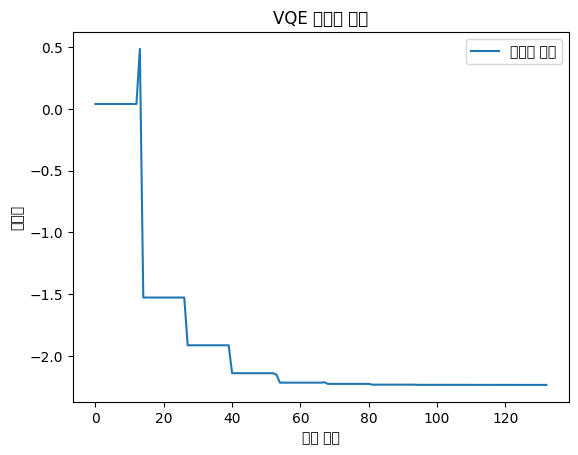

In [10]:
# 에너지 수렴 그래프
plt.plot(energy_values, label='에너지 수렴')
plt.xlabel('반복 횟수')
plt.ylabel('에너지')
plt.title('VQE 에너지 수렴')
plt.legend()
plt.show()

In [11]:
# 바닥상태용 양자회로 정의
ground_state_circuit = ansatz.assign_parameters(result.optimal_point)

In [12]:
# AerSimulator 백엔드용으로 회로 트랜스파일
qc_transpiled = transpile(ground_state_circuit, backend=backend)

In [13]:
# 시각화를 위해 측정 추가
qc_transpiled.measure_all()

In [14]:
# 트랜스파일된 회로를 AerSimulator에서 실행
job = backend.run(qc_transpiled)
counts = job.result().get_counts()

In [15]:
# 시각화를 위해 상태벡터 시뮬레이션
state = Statevector.from_label('00').evolve(ground_state_circuit)

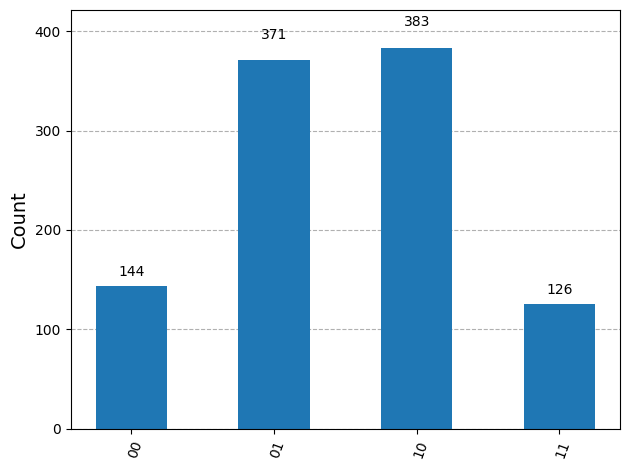

In [16]:
# 측정 카운트 히스토그램 그리기
plot_histogram(counts)
plt.show()

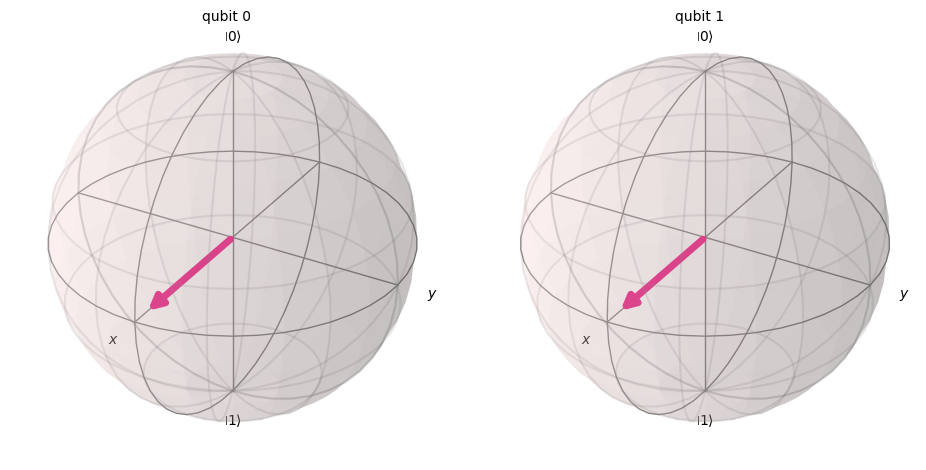

In [17]:
# 상태벡터의 블로흐 구 표현 그리기
plot_bloch_multivector(state)
plt.show()

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/mpl_toolkits/mplot3d/art3d.py:1403: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


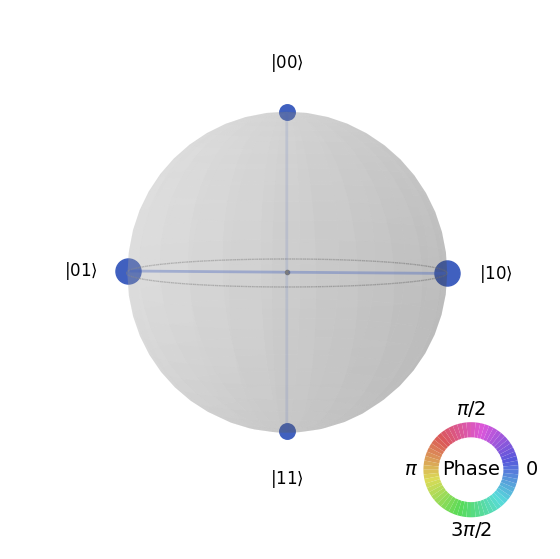

In [18]:
# QSphere 표현 그리기
plot_state_qsphere(state)
plt.show()

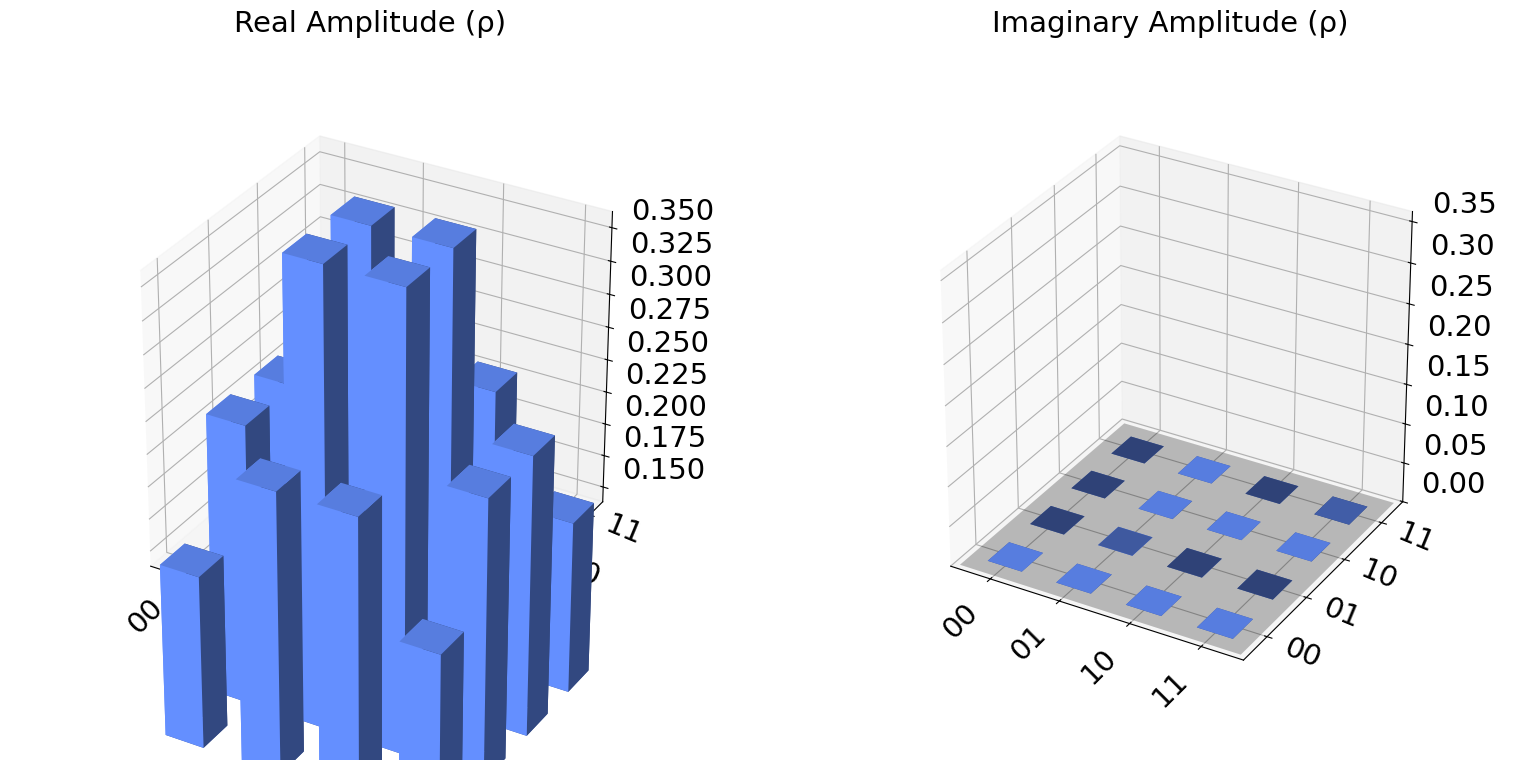

In [19]:
# State City 시각화 그리기
plot_state_city(state)
plt.show()

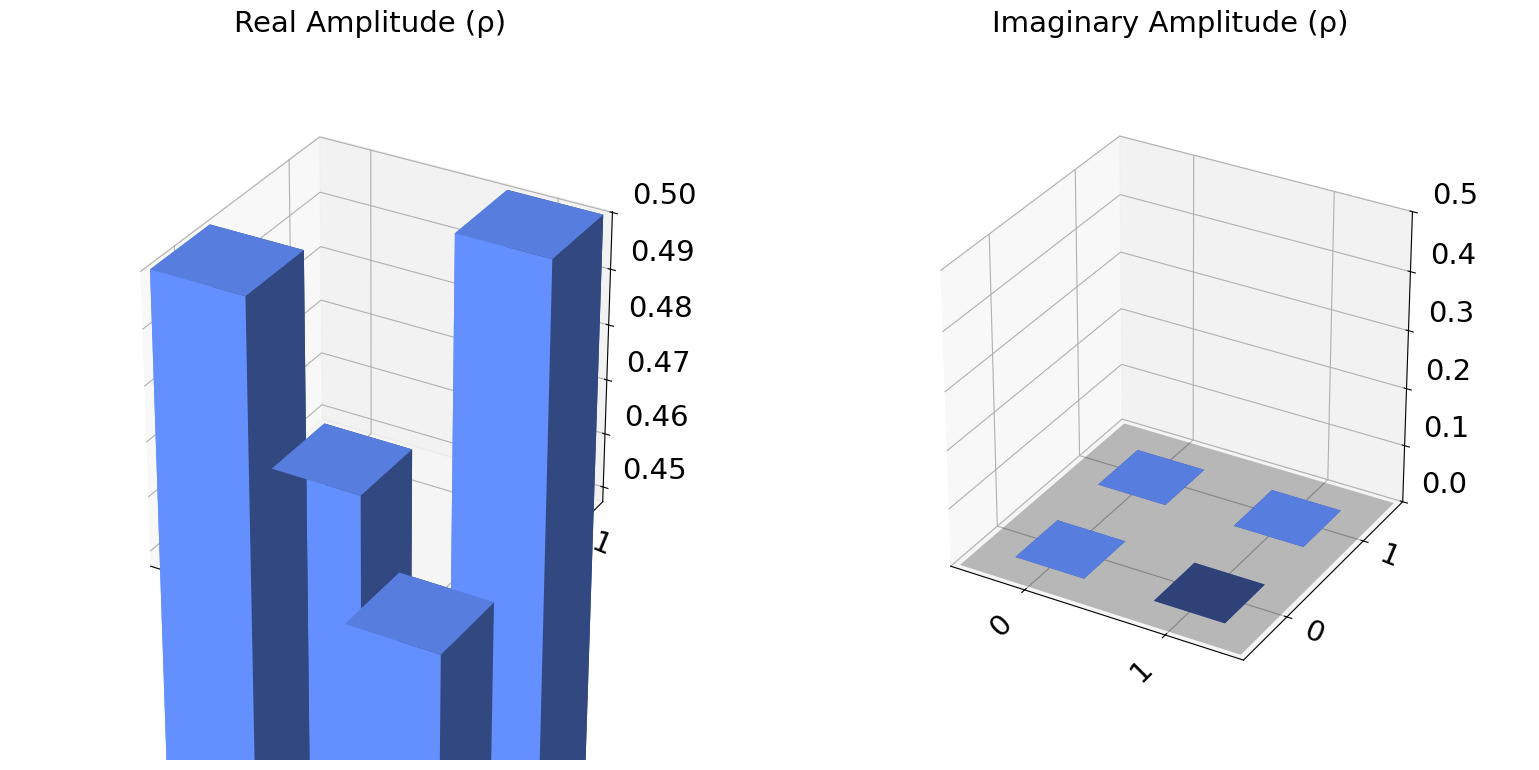

In [20]:
# 부분 대각합 그리기 (첫 큐비트)
rho = state.to_operator().data
partial_traced_rho = partial_trace(rho, [0])
plot_state_city(partial_traced_rho)
plt.show()

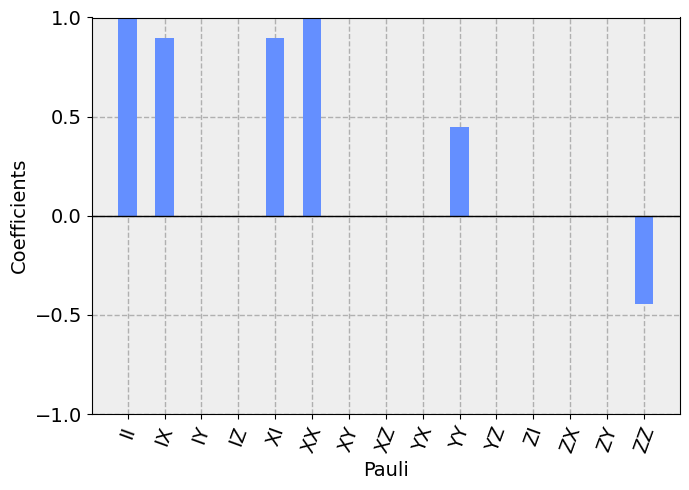

In [21]:
# 파울리 벡터 시각화 (선택)
plot_state_paulivec(state)
plt.show()